In [35]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [36]:
DIR = Path(r"")
IMU_ID = 1
IMU_FILE = DIR / f"imu_{IMU_ID:03d}.csv"

In [37]:
def parse_csv(f: Path) -> np.ndarray:
    """
    读取CSV,返回imu数据。
    [0] - 时间戳
    [1,2,3] - 加速度xyz
    [4,5,6] - 陀螺仪xyz
    """
    data = np.genfromtxt(f, delimiter=',', skip_header=1, usecols=(1, 2, 3, 4, 5, 6, 7))
    return data.T


In [38]:
imu_data = parse_csv(IMU_FILE)
imu_data=imu_data[:, :125000]

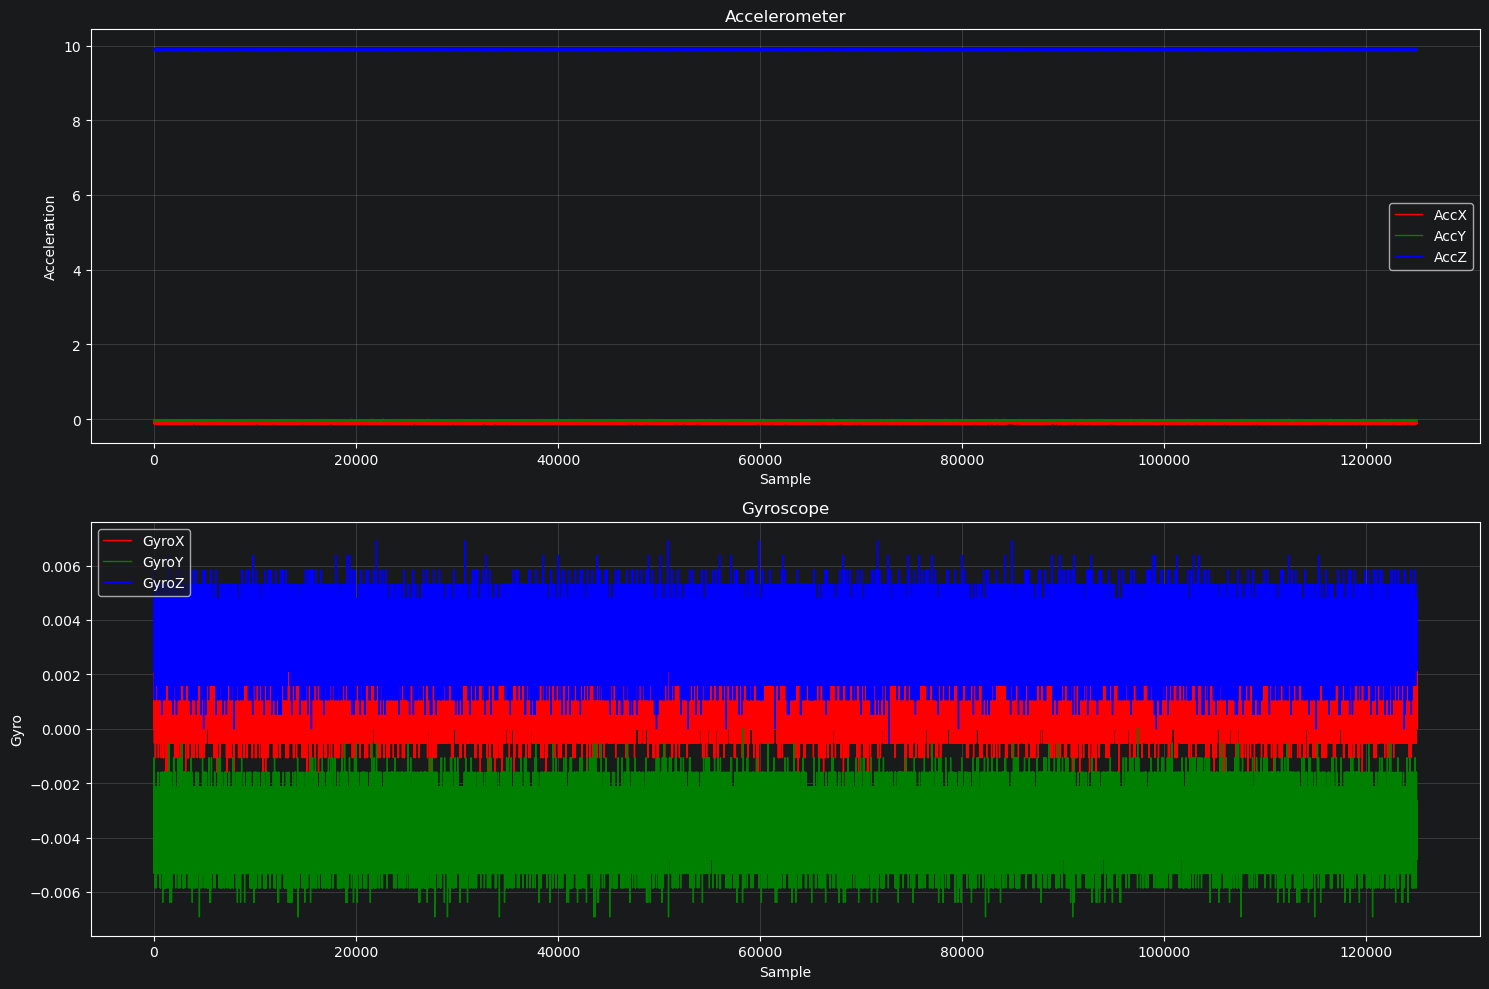

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
acc_labels = ['AccX', 'AccY', 'AccZ']
gyro_labels = ['GyroX', 'GyroY', 'GyroZ']
colors = ['r', 'g', 'b']
acc = imu_data[1:4]
gyro = imu_data[4:7]

# 画加速度计
for i in range(3):
    axes[0].plot(acc[i], label=acc_labels[i], color=colors[i], linewidth=1)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Acceleration')
axes[0].set_title('Accelerometer')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 画陀螺仪
for i in range(3):
    axes[1].plot(gyro[i], label=gyro_labels[i], color=colors[i], linewidth=1)
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Gyro')
axes[1].set_title('Gyroscope')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

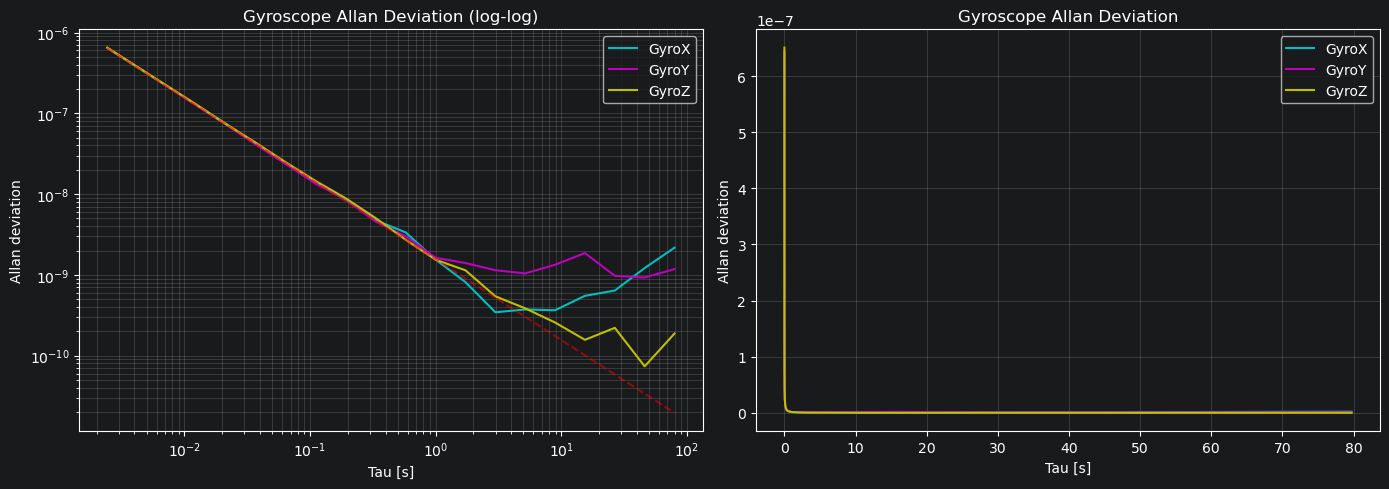

In [40]:
def allan_deviation(data: np.ndarray, sample_period_s: float):
    data = np.asarray(data)
    N = len(data)
    fs = 1 / sample_period_s

    # 最大聚合尺度
    max_m = 2**int(np.floor(np.log2(N // 2)))

    m_values = np.logspace(0, np.log10(max_m), num=20).astype(int)
    m_values = np.unique(m_values)

    taus = m_values / fs
    avar = []

    for m in m_values:
        if 2 * m >= N:
            continue

        # 分段平均
        y = np.array([
            np.mean(data[i:i+m])
            for i in range(0, N - m + 1, m)
        ])

        # Allan variance 计算
        diff = np.diff(y)
        avar_m = 0.5 * np.mean(diff**2)
        avar.append(avar_m)

    return taus[:len(avar)], np.array(avar)


timestamps = imu_data[0]
gyro = imu_data[4:7]
sample_period_s = np.min(np.diff(timestamps)) * 1e-6

allan_results = {}
gyro_labels = ['GyroX', 'GyroY', 'GyroZ']
colors = ['c', 'm', 'y']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(3):
    taus, adev = allan_deviation(gyro[i], sample_period_s)
    allan_results[gyro_labels[i]] = {
        'tau': taus,
        'adev': adev,
    }
    # loglog 图
    axes[0].loglog(taus, adev, label=gyro_labels[i], color=colors[i], linewidth=1.5)
    # 普通 plot 图
    axes[1].plot(taus, adev, label=gyro_labels[i], color=colors[i], linewidth=1.5)

# loglog 图设置
axes[0].set_xlabel('Tau [s]')
axes[0].set_ylabel('Allan deviation')
axes[0].set_title('Gyroscope Allan Deviation (log-log)')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend()

# 添加参考斜率线 (-1)
ref_tau = np.array([taus[0], taus[-1]])
ref_base = allan_results['GyroX']['adev'][0]  # 以 GyroX 起始值为基准
axes[0].loglog(ref_tau, ref_base * (ref_tau / ref_tau[0])**(-1), 'r--', alpha=0.5, label='slope=-1')

# 普通 plot 图设置
axes[1].set_xlabel('Tau [s]')
axes[1].set_ylabel('Allan deviation')
axes[1].set_title('Gyroscope Allan Deviation')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
